### Load and Modify Configuration File

In [12]:
from configs.config_loader import load_config
config = load_config('configs/default.yaml')

version : default
seed : 1
mu : 1.0
x0 : 0.001
x_t0 : 0.0
T : 7.5
N_col : 1024
N_hidden : 4
N_neurons : 50
activation : swish
N_epochs : 25000
learning_rate : 0.001
decay_rate : 1.0
freq_log : 100
freq_print : 1000
keys_print : ['loss_P', 'loss_IC']
freq_save : 1000
regularizer : reg_derivative_unstable_fp
reg_coeff : 10.0
reg_decay : linear
reg_epochs : 0.5


### Initialize Physics-Informed Neural Network

In [13]:
from model.neural_net import PhysicsInformedNN
PINN = PhysicsInformedNN(config, verbose=True)

/home/mbabic/Desktop/PINNs_fixed_points/env/lib/python3.10/site-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "PhysicsInformedNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 50)             │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,801 (30.47 KB)

 Trainable params: 7,801 (30.47 KB)

 Non-trainable params: 0 (0.00 B)

*** PINN build & initialized ***


### Train Physics-Informed Neural Network

In [14]:
training_log = PINN.train()

Training started...


    0/25000 | loss_P: 1.00e+01 | loss_IC: 1.08e-04
 1000/25000 | loss_P: 1.33e+00 | loss_IC: 1.73e-01
 2000/25000 | loss_P: 1.25e+00 | loss_IC: 1.35e-01
 3000/25000 | loss_P: 7.40e-01 | loss_IC: 4.90e-02
 4000/25000 | loss_P: 7.24e-01 | loss_IC: 4.29e-02
 5000/25000 | loss_P: 6.75e-01 | loss_IC: 4.21e-02
 6000/25000 | loss_P: 6.63e-01 | loss_IC: 3.36e-02
 7000/25000 | loss_P: 5.34e-01 | loss_IC: 4.15e-02
 8000/25000 | loss_P: 5.24e-01 | loss_IC: 3.10e-02
 9000/25000 | loss_P: 4.99e-01 | loss_IC: 2.39e-02
10000/25000 | loss_P: 3.77e-01 | loss_IC: 2.42e-02
11000/25000 | loss_P: 2.94e-01 | loss_IC: 1.47e-02
12000/25000 | loss_P: 1.64e-01 | loss_IC: 5.30e-03
13000/25000 | loss_P: 1.74e-04 | loss_IC: 3.92e-05
14000/25000 | loss_P: 3.58e-05 | loss_IC: 4.65e-06
15000/25000 | loss_P: 1.21e-05 | loss_IC: 1.94e-06
16000/25000 | loss_P: 4.80e-06 | loss_IC: 3.86e-07
17000/25000 | loss_P: 2.65e-06 | loss_IC: 1.64e-07
18000/25000 | loss_P: 4.05e-05 | loss_IC: 1.50e-06
19000/25000 | loss_P: 1.25e-06 

# Plot Section

In [15]:
from model.plots import learning_curves, van_der_pol_dynamics, loss_over_tcoll, plot_regularization, results_heatmap, regularization_over_domain

### Learning Curves

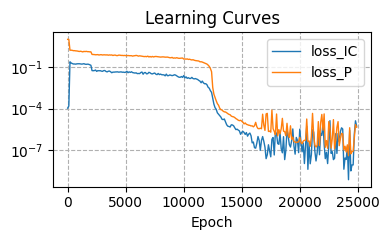

In [16]:
learning_curves(training_log)

### Pendulum Dynamics

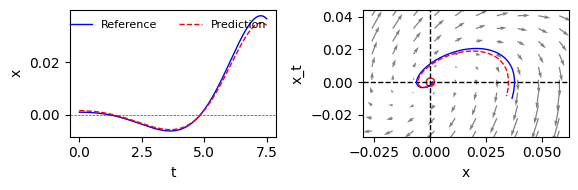

In [17]:
van_der_pol_dynamics(PINN)

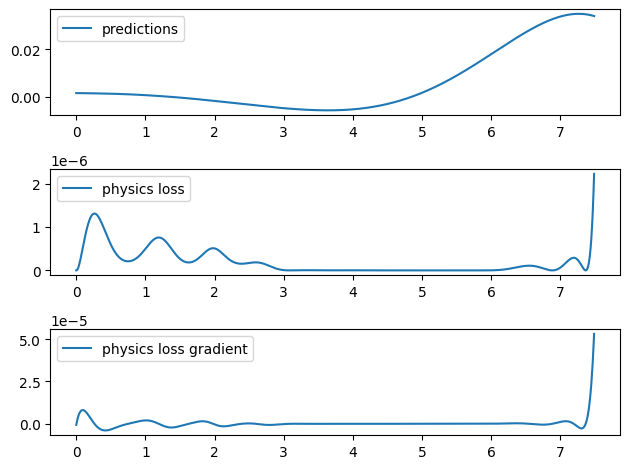

In [18]:
loss_over_tcoll(PINN)

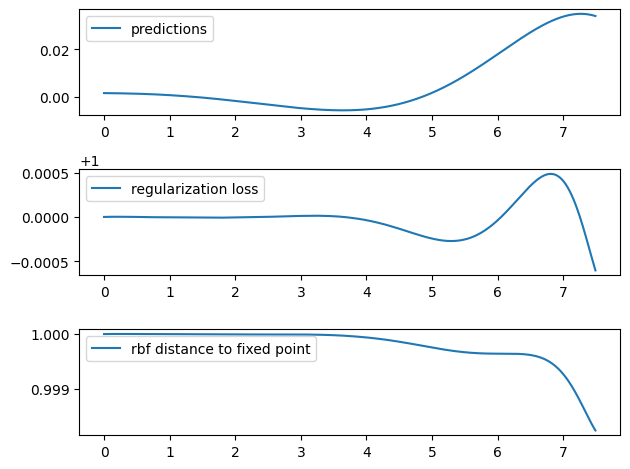

In [19]:
plot_regularization(PINN)

### Regularization landscape

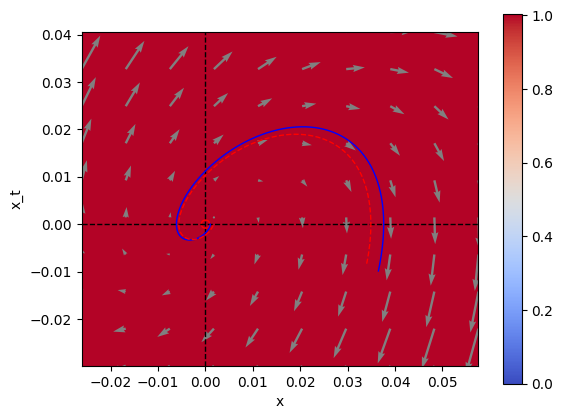

In [20]:
regularization_over_domain(PINN=PINN)

### Training animation

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML



def init_fig():

    fig, ax = plt.subplots()

    #############################
    ### Initial plot comes here
    #############################

    plt.tight_layout()
    plt.close(fig)
    return fig, ax


def animate(i, *fargs):
    # get passed arguments
    ax = fargs[0]
    N_times = fargs[1]

    # print status of animation
    print(f'Processed: {i/N_times*100:.0f}%', end='\r')

    # clear axis
    ax.clear()
    #############################
    ### load model weights & make predictions
    #############################
    flag = i * config['freq_save']
    PINN.load_weights(PINN.log_path.joinpath(f'model_weights/weights_{flag}.pkl'))

    ############################
    # Prediciton plot
    ############################

    # stable/unstable fixed points
    line_props = {'ls': '--', 'lw': 0.5}
    ax.axhline(0, c='green', **line_props)
    ax.axhline(np.pi, c='red', **line_props)
    ax.axhline(-np.pi, c='red', **line_props)

    # Reference data and PINN prediction
    t_line, theta_true, omega_true = PINN.data.reference()
    theta_pred = PINN(t_line)
    
    ##############################
    ### Regularization coefficient
    ##############################
    epoch = flag
    coeff = config["reg_coeff"]
    if config["reg_decay"] == "linear":
        coeff = config["reg_coeff"] * (1 - epoch / config["reg_epochs"])
    
    ax.plot([], [], c='black', lw=1, label=f'regularization coeff {coeff}')
           
    #############################
    ### Updated plot comes here
    #############################

    # make plot
    ax.plot(t_line, theta_true, c='blue', lw=1, label='Reference')
    ax.plot(t_line, theta_pred, c='red', lw=1, ls='--', label='Prediction')

    # Axis appearance
    ax.set_xlabel(r'$t$')
    ax.set_ylabel(r'$\theta$')
    ax.legend(frameon=False, loc=1, ncol=2, fontsize=8)
    ax.set_ylim([-3.5, 3.5])
    


    plt.tight_layout()


# should equal the number of saved weights files
N_frames = int(config["N_epochs"] / config["freq_save"])

(fig, ax) = init_fig()
ani = FuncAnimation(fig, animate, frames=N_frames, fargs=(ax, N_frames))
HTML(ani.to_jshtml())

<Figure size 640x480 with 0 Axes>

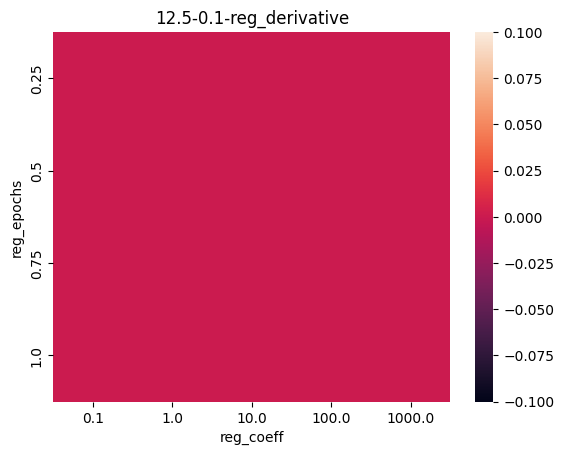

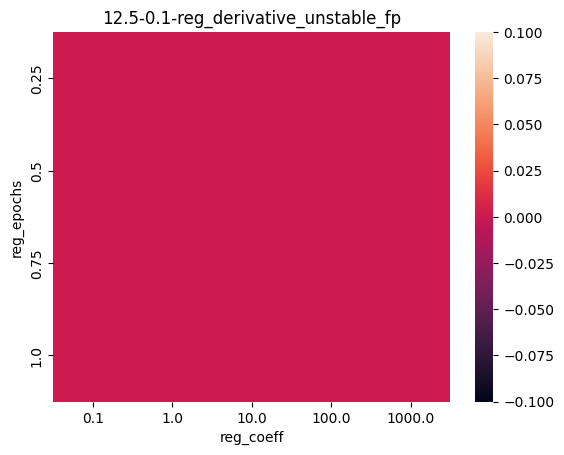

In [22]:
import pandas as pd
import numpy as np
from model.plots import results_linear_decay
results = pd.read_csv("results_linear_decay.csv")

results_linear_decay(results)